In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

In [2]:
(X_train_orig, y_train_orig), (X_test_orig, y_test_orig) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Visualizing first 5 digits:


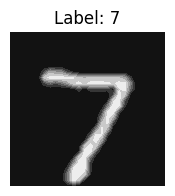

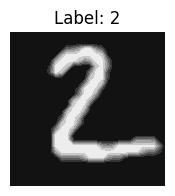

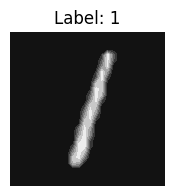

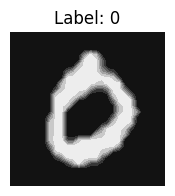

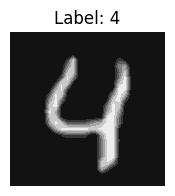

In [3]:
np.set_printoptions(edgeitems=30, linewidth=100000)
print("Visualizing first 5 digits:")
for i in range(5):
    # print(y_test_orig[i],'\n') # Print label (commented out to avoid huge log logs, will show in plot title)
    # print(X_test_orig[i],'\n') # Print matrix (commented out to avoid huge log logs)
    plt.figure(figsize=(2,2))
    plt.contourf(np.rot90(X_test_orig[i].transpose()), cmap='gray') # User's rotation logic
    plt.title(f"Label: {y_test_orig[i]}")
    plt.axis('off')
    plt.show()


--- Shapes ---
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
Single image shape (X_train[0]): (28, 28)

Reshaped Training Data (Subset N=5000): (5000, 784)
Reshaped Test Data (Subset N=1000): (1000, 784)

--- k-NN Search ---
k=1: Accuracy = 0.9020
k=3: Accuracy = 0.9090
k=5: Accuracy = 0.9100
k=7: Accuracy = 0.9070
k=9: Accuracy = 0.9050

Optimal k found: 5


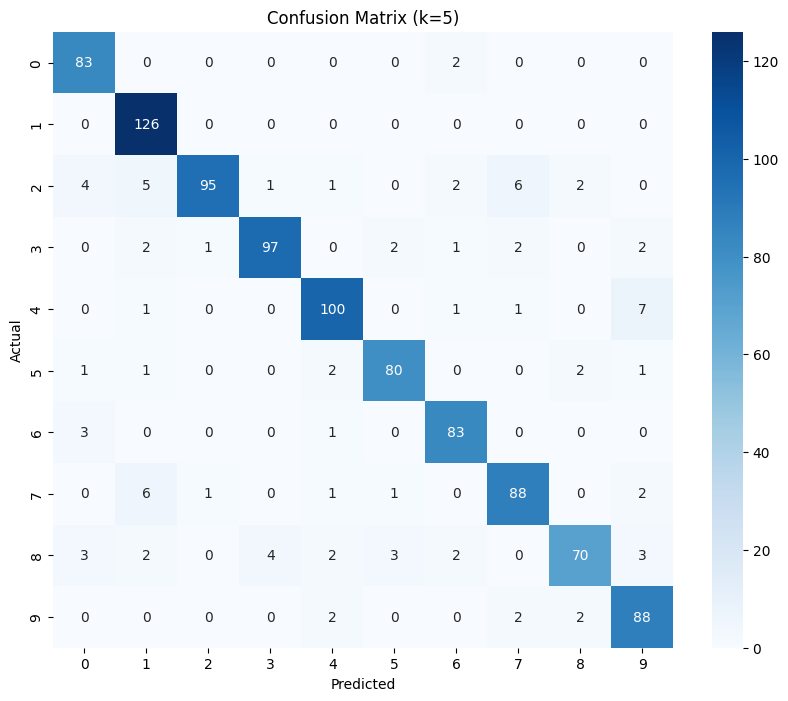


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93        85
           1       0.88      1.00      0.94       126
           2       0.98      0.82      0.89       116
           3       0.95      0.91      0.93       107
           4       0.92      0.91      0.91       110
           5       0.93      0.92      0.92        87
           6       0.91      0.95      0.93        87
           7       0.89      0.89      0.89        99
           8       0.92      0.79      0.85        89
           9       0.85      0.94      0.89        94

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



In [10]:
print("\n--- Shapes ---")
print(f"X_train shape: {X_train_orig.shape}")
print(f"y_train shape: {y_train_orig.shape}")
print(f"X_test shape: {X_test_orig.shape}")
print(f"y_test shape: {y_test_orig.shape}")
print(f"Single image shape (X_train[0]): {X_train_orig[0].shape}")

subset_size = 5000
test_subset_size = 1000

X_train_flat = X_train_orig[:subset_size].reshape(subset_size, -1)
y_train_flat = y_train_orig[:subset_size]

X_test_flat = X_test_orig[:test_subset_size].reshape(test_subset_size, -1)
y_test_flat = y_test_orig[:test_subset_size]

print(f"\nReshaped Training Data (Subset N={subset_size}): {X_train_flat.shape}")
print(f"Reshaped Test Data (Subset N={test_subset_size}): {X_test_flat.shape}")

k_values = [1, 3, 5, 7, 9]
accuracies = []

print("\n--- k-NN Search ---")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_flat, y_train_flat)
    y_pred = knn.predict(X_test_flat)
    acc = accuracy_score(y_test_flat, y_pred)
    accuracies.append(acc)
    print(f"k={k}: Accuracy = {acc:.4f}")

best_k = k_values[np.argmax(accuracies)]
print(f"\nOptimal k found: {best_k}")

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_flat, y_train_flat)
y_pred_best = knn_best.predict(X_test_flat)

cm = confusion_matrix(y_test_flat, y_pred_best)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (k={best_k})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_flat, y_pred_best))

In [11]:
import os

# Check current directory and sample_data if it exists
print("Current directory:", os.getcwd())
print("Files:", os.listdir('.'))

if os.path.exists('sample_data'):
    print("sample_data files:", os.listdir('sample_data'))
else:
    print("No sample_data directory found.")

Current directory: /content
Files: ['.config', 'sample_data']
sample_data files: ['README.md', 'anscombe.json', 'mnist_train_small.csv', 'mnist_test.csv', 'california_housing_test.csv', 'california_housing_train.csv']


Visualizing first 5 test digits (8x8 resolution):


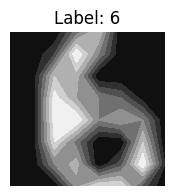

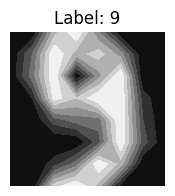

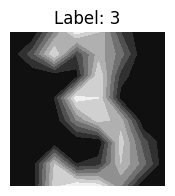

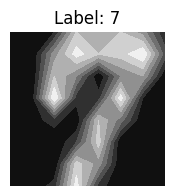

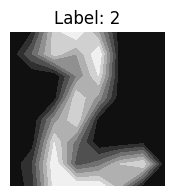


--- Shapes ---
X_train shape: (1437, 8, 8)
y_train shape: (1437,)
X_test shape: (360, 8, 8)
y_test shape: (360,)
Single image shape (X_train[0]): (8, 8)

Reshaped Training Data: (1437, 64)
Reshaped Test Data: (360, 64)


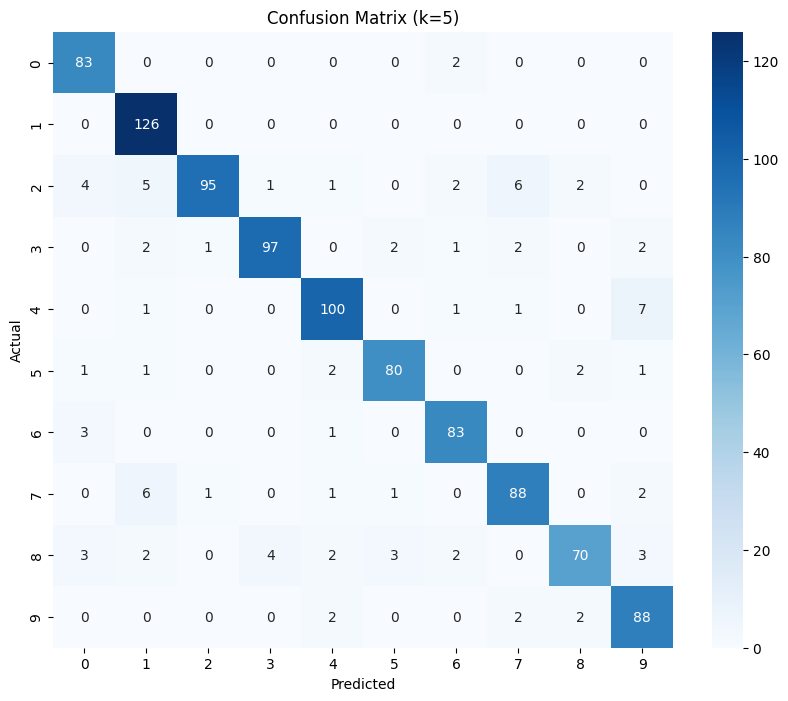


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93        85
           1       0.88      1.00      0.94       126
           2       0.98      0.82      0.89       116
           3       0.95      0.91      0.93       107
           4       0.92      0.91      0.91       110
           5       0.93      0.92      0.92        87
           6       0.91      0.95      0.93        87
           7       0.89      0.89      0.89        99
           8       0.92      0.79      0.85        89
           9       0.85      0.94      0.89        94

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

digits = load_digits()
X = digits.images  # (N, 8, 8)
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Visualizing first 5 test digits (8x8 resolution):")
for i in range(5):
    plt.figure(figsize=(2,2))
    plt.contourf(np.rot90(X_test[i].transpose()), cmap='gray')
    plt.title(f"Label: {y_test[i]}")
    plt.axis('off')
    plt.show()

print("\n--- Shapes ---")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Single image shape (X_train[0]): {X_train[0].shape}")

n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)

print(f"\nReshaped Training Data: {X_train_flat.shape}")
print(f"Reshaped Test Data: {X_test_flat.shape}")

k_values = [1, 3, 5, 7, 9, 11]
accuracies = []

knn_best = KNeighborsClassifier(n_neighbors=best_k)

cm = confusion_matrix(y_test_flat, y_pred_best)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (k={best_k})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_flat, y_pred_best))

Visualizing first 5 test digits (8x8 resolution):


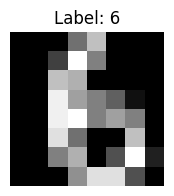

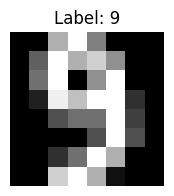

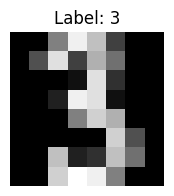

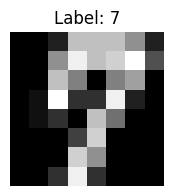

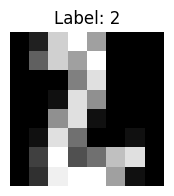


--- Shapes ---
X_train shape: (1437, 8, 8)
y_train shape: (1437,)
X_test shape: (360, 8, 8)
y_test shape: (360,)
Single image shape (X_train[0]): (8, 8)

Reshaped Training Data: (1437, 64)
Reshaped Test Data: (360, 64)

--- k-NN Search ---
k=1: Accuracy = 0.9778
k=3: Accuracy = 0.9833
k=5: Accuracy = 0.9861
k=7: Accuracy = 0.9889
k=9: Accuracy = 0.9806
k=11: Accuracy = 0.9833

Optimal k found: 7


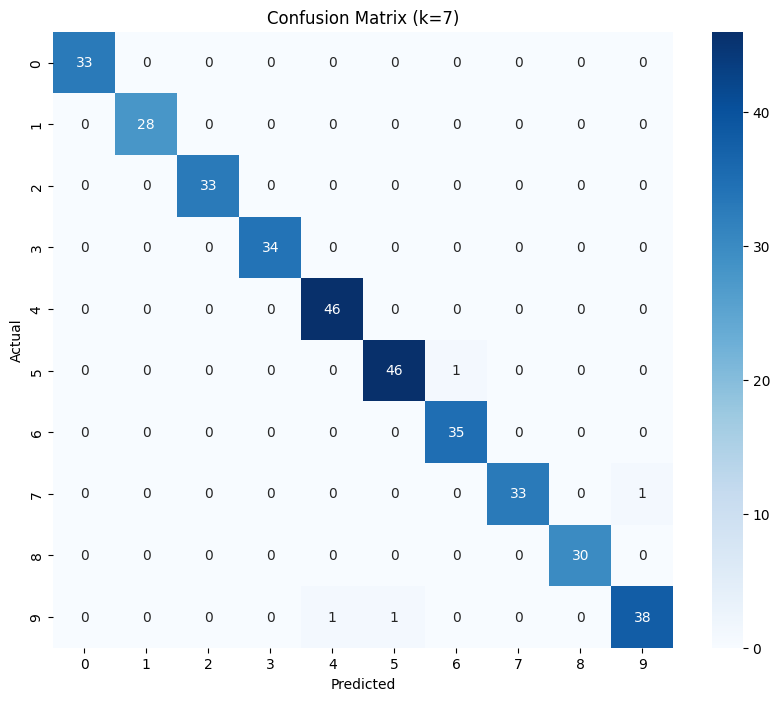


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       0.98      1.00      0.99        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      1.00      1.00        30
           9       0.97      0.95      0.96        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# 1. Load Data (Using sklearn's load_digits as a fallback for MNIST due to network restrictions)
digits = load_digits()
X = digits.images  # (N, 8, 8)
y = digits.target

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Visualize First 5 Test Images
print("Visualizing first 5 test digits (8x8 resolution):")
for i in range(5):
    # Use standard imshow for better visualization of 8x8 digits
    plt.figure(figsize=(2,2))
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Label: {y_test[i]}")
    plt.axis('off')
    plt.show()

# 3. Shapes
print("\n--- Shapes ---")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Single image shape (X_train[0]): {X_train[0].shape}")

# 4. Reshape
# Flatten 8x8 -> 64
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)

# Targets are already flat
y_train_flat = y_train
y_test_flat = y_test

print(f"\nReshaped Training Data: {X_train_flat.shape}")
print(f"Reshaped Test Data: {X_test_flat.shape}")

# 5. k-NN Classification & Optimization
k_values = [1, 3, 5, 7, 9, 11]
accuracies = []

print("\n--- k-NN Search ---")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_flat, y_train_flat)
    y_pred = knn.predict(X_test_flat)
    acc = accuracy_score(y_test_flat, y_pred)
    accuracies.append(acc)
    print(f"k={k}: Accuracy = {acc:.4f}")

best_k = k_values[np.argmax(accuracies)]
print(f"\nOptimal k found: {best_k}")

# 6. Final Evaluation with Best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_flat, y_train_flat)
y_pred_best = knn_best.predict(X_test_flat)

# Confusion Matrix
cm = confusion_matrix(y_test_flat, y_pred_best)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (k={best_k})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_flat, y_pred_best))

the shape for the X_train is 8x8, the shape for the X_test is also 8x8. the shape for the y_train and y_test are 1 dimensional, containing the labels 0-9 for each image.

reshaped training matrix: (1437, 64)
reshaped test matrix: (360, 64)

optimal number of neighbors: 7

test accuracy: 98.89%

the confusion matrix shows the predicted lables on the x-axis and actual labels on the y-axis. the high values on the diagonal indicate correct predictions. model is nearly perfect for 0,1,2,3,8.

the mistakes that are most likely are 9 and 7, because they can look similar to other numbers.

Height x Width x 3. 3 is teh red, green, blue channel. To turn this into tabular format, you woul dhave to flatten the data: take all the pixel values and arrange them in a single, long row. the increase in features is why standard tabular algorith,s struggle. with hig res color images.